In [1]:
from typing import Optional, Dict

# neural_transport
from neural_transport.models import MODELS
from neural_transport.models.wrappers_registry import MODELWRAPPERS
#from neural_transport.models.regulargrid import RegularGridModel
#from neural_transport.models.unet import UNet
from neural_transport.models.layers import (
    ACTIVATIONS,
    MultiScaleDecoder,
    MultiScaleEncoder,
)
from neural_transport.tools.conversion import *
from neural_transport.datasets.grids import (
    LATLON_PROTOTYPE_COORDS,
    VERTICAL_LAYERS_PROTOTYPE_COORDS,
)
from neural_transport.datamodule import CarbonDataModule

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm

# numpy
import numpy as np

# torch
import pytorch_lightning as pl
import torch
import torch.nn as nn

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import ODESolver


/Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /lib64/libc.so.6: version `GLIBC_2.32' not found (required by /Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/torch_scatter/_version_cuda.so)
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/torch_geometric/typing.py:97: User

In [2]:
torch.set_float32_matmul_precision("high")
pl.seed_everything(42)

Seed set to 42


42

In [56]:
# RegularGridModel

class RegularGridModel(nn.Module):

    def __init__(
        self,
        model_kwargs={},
        input_vars=[],
        target_vars=[],
        nlat=45,
        nlon=72,
        nlev=None,
        predict_delta=False,
        add_surfflux=False,
        massfixer=None,
        dt=3600,
        molecules=["co2"],
        targshift=False,
        vert_pos_embed=False,
        vert_pos_embed_kwargs=None,
        horizontal_interpolation=None,
        in_nlat=None,
        in_nlon=None,
        multiscale_kwargs=dict(in_chans=5, out_chans=128, layer_norm=True, act="swish"),
    ):
        super().__init__()

        self.nlat = nlat
        self.nlon = nlon
        self.nlev = nlev
        self.input_vars = input_vars
        self.target_vars = target_vars

        self.in_nlat = in_nlat or nlat
        self.in_nlon = in_nlon or nlon
        self.horizontal_interpolation = horizontal_interpolation

        self.predict_delta = predict_delta
        self.add_surfflux = add_surfflux
        self.dt = dt
        self.massfixer = massfixer
        self.molecules = molecules
        self.targshift = targshift

        if self.horizontal_interpolation == "multiscale_encoder":
            self.multiscale_encoder = MultiScaleEncoder(
                in_shape=(self.in_nlat, self.in_nlon),
                out_shape=(self.nlat, self.nlon),
                **multiscale_kwargs,
            )
            self.multiscale_decoder = MultiScaleDecoder(
                in_shape=(self.in_nlat, self.in_nlon),
                out_shape=(self.nlat, self.nlon),
                **multiscale_kwargs,
            )
        self.init_model(**model_kwargs)

    def init_model(self, **model_kwargs):
        raise NotImplementedError

    def model(self):
        raise NotImplementedError

    def forward(self, batch, normalize=True, denormalize=True):
        x_in = self.preprocess_inputs(batch, normalize=normalize)
        x_out = self.model(x_in)
        preds = self.postprocess_outputs(x_out, batch, denormalize=denormalize)
        return preds

    def normalize_batch(self, batch):
        batch_normalized = {}
        vars_to_normalize = self.input_vars
        for v in vars_to_normalize:
            # print(f"input: {v}")
            if v not in batch:
                print(f"WARNING: skipping {v}, missing in batch")
                continue

            try:
                offset = batch[f"{v}_offset"]
                scale = batch[f"{v}_scale"]
            except KeyError as e:
                raise KeyError(
                    f"Missing offset/scale for input variable '{v}' during normalization: {e}."
                    f"Expected keys: {v}_offset, {v}_scale. "
                    f"Available keys: {list(batch.keys())}"
                )
            
            x_in_curr = (batch[v] - offset) / scale

            if self.targshift and (v in self.target_vars):
                batch_normalized[v] = x_in_curr - x_in_curr.mean((1, 2), keepdim=True)
            else:
                batch_normalized[v] = x_in_curr

        return batch_normalized

    def preprocess_inputs(self, batch, normalize=True):
        print("preprocess inputs")
        if normalize:
            batch_normalized = self.normalize_batch(batch)
        else:
            batch_normalized = batch

        x_in = torch.cat(list(batch_normalized.values()), dim=-1)

        B, N, C = x_in.shape

        x_in = x_in.reshape(B, self.in_nlat, self.in_nlon, C).permute(
            0, 3, 1, 2
        )  # b c h w

        if self.horizontal_interpolation == "multiscale_encoder":
            x_in = self.multiscale_encoder(x_in)

        elif self.horizontal_interpolation is not None:
            x_in = nn.functional.interpolate(
                x_in,
                size=(self.nlat, self.nlon),
                align_corners=True,
                mode=self.horizontal_interpolation,
            )

        # if not x_in.isfinite().all():
        #     print("x_in not finite", x_in.min(), x_in.mean(), x_in.max())

        return x_in
    
    def normalize_batch_target_vars(self, batch):
        
        batch_normalized = {}
        for v in self.target_vars:
            # print(f"target: {v}")
            for suffix in ['', '_next']:
                key = f"{v}{suffix}"
                if key in batch.keys():
                    mean = batch[f"{v}_offset"]
                    std = batch[f"{v}_scale"]
                    x_in_curr = (batch[key] - mean) / std
                    if self.targshift:
                        batch_normalized[key] = x_in_curr - x_in_curr.mean((1, 2), keepdim=True)
                    else:
                        batch_normalized[key] = x_in_curr
        return batch_normalized
    
    def postprocess_outputs(self, x_out, batch, denormalize=True):

        B, N, _ = batch[self.target_vars[0]].shape
        print("postprocess outputs")
        if self.horizontal_interpolation == "multiscale_encoder":
            x_out = self.multiscale_decoder(x_out)
        elif self.horizontal_interpolation is not None:
            x_out = nn.functional.interpolate(
                x_out,
                size=(self.in_nlat, self.in_nlon),
                align_corners=True,
                mode=self.horizontal_interpolation,
            )

        x_out = x_out.permute(0, 2, 3, 1).reshape(B, N, -1)
        
        if denormalize:
            x_grid_offset = torch.cat(
                [(batch[f"{v}_offset"]).expand_as(batch[v]) for v in self.target_vars],
                dim=-1,
            )
            x_grid_scale = torch.cat(
                [(batch[f"{v}_scale"]).expand_as(batch[v]) for v in self.target_vars],
                dim=-1,
            )

            x_out_prev = torch.cat(
                [batch[v] for v in self.target_vars],
                dim=-1,
            )
            
            x_grid_delta_offset = torch.cat(
                [
                    (batch[f"{v}_delta_offset"]).expand_as(batch[v])
                    for v in self.target_vars
                ],
                dim=-1,
            )
            x_grid_delta_scale = torch.cat(
                [(batch[f"{v}_delta_scale"]).expand_as(batch[v]) for v in self.target_vars],
                dim=-1,
            )

            # if not x_out.isfinite().all():
            #     print("x_out not finite", x_out.min(), x_out.mean(), x_out.max())

            if self.predict_delta:
                x_out_resc = x_out * x_grid_delta_scale + x_grid_delta_offset

                x_out_next = x_out_prev + x_out_resc
            else:
                x_out_next = x_out * x_grid_scale + x_grid_offset
        else:
            x_out_next = x_out
            
        # if not x_out_next.isfinite().all():
        #     print(
        #         "x_out_next not finite",
        #         x_out_next.min(),
        #         x_out_next.mean(),
        #         x_out_next.max(),
        #     )

        preds = {}
        i = 0
        for v in self.target_vars:
            C = batch[v].shape[-1]
            preds[v] = x_out_next[..., i : i + C]
            i += C
        
        for molecule in self.molecules:

            # mass_pred_pre_fixer = (
            #     (preds[f"{molecule}massmix"] / 1e6) * batch["airmass_next"]
            # ).sum((1, 2), keepdim=True)

            if self.massfixer and (not self.training):

                mass_pred = (preds[f"{molecule}massmix"]) * batch["airmass_next"]

                mass_old = (batch[f"{molecule}massmix"]) * batch["airmass"]
                if not self.add_surfflux:
                    surfflux_as_masssource = (
                        (
                            batch[f"{molecule}flux_land"]
                            + batch[f"{molecule}flux_ocean"]
                            + batch[f"{molecule}flux_anthro"]
                        )
                        * batch["cell_area"]
                        * self.dt
                        / 1e6  # / 1e12  # PgCO2
                    )
                    B, N, C = mass_old.shape
                    mass_old = mass_old + (
                        surfflux_as_masssource.sum((1, 2), keepdim=True) / (N * C)
                    )
                if self.massfixer == "shift":

                    preds[f"{molecule}massmix"] = (
                        (
                            mass_pred
                            - mass_pred.mean((1, 2), keepdim=True)
                            + mass_old.mean((1, 2), keepdim=True)
                        )
                    ) / batch["airmass_next"]

                elif self.massfixer == "scale":

                    preds[f"{molecule}massmix"] = (
                        (
                            mass_pred
                            * mass_old.mean((1, 2), keepdim=True)
                            / mass_pred.mean((1, 2), keepdim=True)
                        )
                    ) / batch["airmass_next"]

            # mass_pred_after_fixer = (
            #     (preds[f"{molecule}massmix"] / 1e6) * batch["airmass_next"]
            # ).sum((1, 2), keepdim=True)

            if self.add_surfflux:

                surfflux_as_massmixsource_prev = (
                    (
                        batch[f"{molecule}flux_land"]
                        + batch[f"{molecule}flux_ocean"]
                        + batch[f"{molecule}flux_anthro"]
                    )
                    * batch["cell_area"]
                    * self.dt
                    / 1e6  # / 1e12  # PgCO2
                ) / batch["airmass_next"][
                    ..., :1
                ]  # * 1e6

                preds[f"{molecule}massmix"][..., :1] = (
                    preds[f"{molecule}massmix"][..., :1]
                    + surfflux_as_massmixsource_prev
                )

            ### NOTE: Roughly 0.5% Mass Error remains !!!
            ### THIS IS IN THE DATA ALREADY :/ don't know why.

            # virtual_pred = batch[f"{molecule}massmix"].clone()
            # virtual_pred = virtual_pred * batch["airmass"] / batch["airmass_next"]
            # virtual_pred[..., :1] = (
            #     virtual_pred[..., :1] + surfflux_as_massmixsource_prev
            # )

            # mass_pred = (
            #     (preds[f"{molecule}massmix"] / 1e6) * batch["airmass_next"]
            # ).sum((1, 2), keepdim=True)
            # mass_virtual = ((virtual_pred / 1e6) * batch["airmass_next"]).sum(
            #     (1, 2), keepdim=True
            # )
            # mass_targ = (
            #     (batch[f"{molecule}massmix_next"] / 1e6) * batch["airmass_next"]
            # ).sum((1, 2), keepdim=True)
            # mass_old = ((batch[f"{molecule}massmix"] / 1e6) * batch["airmass"]).sum(
            #     (1, 2), keepdim=True
            # )

            # rmse_mass = ((mass_targ - mass_pred) ** 2).mean() ** 0.5
            # rmse_pre = ((mass_targ - mass_pred_pre_fixer) ** 2).mean() ** 0.5
            # rmse_zero = ((mass_old - mass_pred_after_fixer) ** 2).mean() ** 0.5
            # rmse_post = ((mass_targ - mass_pred_after_fixer) ** 2).mean() ** 0.5
            # rmse_virtual = ((mass_targ - mass_virtual) ** 2).mean() ** 0.5

            # rmse_delta = ((mass_targ - mass_old) ** 2).mean() ** 0.5

            # print(
            #     f"RMSE in {molecule} mass: {rmse_mass:.5f}, RMSE Delta: {rmse_delta:.5f}, RMSE PreFixer: {rmse_pre:.5f}, RMSE PostFixer: {rmse_post:.5f}, RMSE Virtual {rmse_virtual:.5f}, RMSE Zero {rmse_zero:.5f}"
            # )
            # breakpoint()

        return preds


In [50]:
# UNet

def get_norm(norm, n_in, n_groups=8):

    if norm == "batch":
        return nn.BatchNorm2d(n_in)
    elif norm == "group":
        return nn.GroupNorm(n_groups, n_in)
    elif norm == "instance":
        return nn.InstanceNorm2d(n_in, affine=True)
    else:
        return nn.Identity()


class PeriodicPadding(nn.Module):

    def __init__(self, n_pad):
        super().__init__()
        self.n_pad = n_pad

    def forward(self, x):

        x = nn.functional.pad(
            x, (self.n_pad, self.n_pad, 0, 0), mode="circular"
        )  # torch.cat([x[:, :, -self.n_pad:, :], x, x[:, :, :self.n_pad, :]], dim = 2)

        x = nn.functional.pad(
            x, (0, 0, self.n_pad, self.n_pad), mode="constant", value=0
        )

        return x

class ResBlock(nn.Module):

    def __init__(
        self,
        n_in,
        embed_dim,
        act="leakyrelu",
        norm="batch",
        filter_size=3,
        add_skip=True,
    ):
        super().__init__()

        n_pad = (filter_size - 1) // 2

        self.pad = PeriodicPadding(n_pad)

        self.conv = nn.Conv2d(
            n_in, embed_dim, filter_size, stride=1, padding=0, bias=(norm is None)
        )

        self.act = ACTIVATIONS[act]()

        self.norm = get_norm(norm, embed_dim)
        self.add_skip = add_skip

    def forward(self, x):

        skip = x

        x = self.pad(x)
        x = self.conv(x)
        x = self.act(x)
        x = self.norm(x)

        if self.add_skip and (skip.shape == x.shape):
            x = x + skip

        return x


class UNet(RegularGridModel):

    def init_model(
        self,
        in_chans=193,
        out_chans=19,
        embed_dim=128,
        act="leakyrelu",
        norm="batch",
        enc_filters=[[7], [3, 3], [3, 3], [3, 3]],
        dec_filters=[[3, 3], [3, 3], [3, 3], [3, 3]],
        in_interpolation="bilinear",
        out_interpolation="nearest-exact",
        readout_act="none",
        mlp_as_readout=False,
        out_clip=None,
    ):

        self.in_chans = in_chans
        self.out_chans = out_chans
        self.in_interpolation = in_interpolation
        self.out_interpolation = out_interpolation
        self.out_clip = out_clip

        depth = len(enc_filters)
        assert depth == len(dec_filters)

        self.resc_lat = ((self.nlat // (2**depth)) + 1) * (2**depth)
        self.resc_lon = ((self.nlon // (2**depth)) + 1) * (2**depth)

        self.embed_dim = embed_dim

        enc_stages = []
        for i, filters in enumerate(enc_filters):
            enc_stage = []
            if i > 0:
                enc_stage.append(nn.MaxPool2d(2, 2))
            for j, filter_size in enumerate(filters):
                n_in = in_chans if (i == 0) and (j == 0) else embed_dim
                enc_stage.append(
                    ResBlock(
                        n_in, embed_dim, act=act, norm=norm, filter_size=filter_size
                    )
                )
            enc_stages.append(nn.Sequential(*enc_stage))

        self.enc_stages = nn.ModuleList(enc_stages)

        dec_stages = []
        for i, filters in enumerate(dec_filters):
            dec_stage = []
            for j, filter_size in enumerate(filters):
                dec_stage.append(
                    ResBlock(
                        embed_dim,
                        embed_dim,
                        act=act,
                        norm=norm,
                        filter_size=filter_size,
                    )
                )

            if i != (len(dec_filters) - 1):
                dec_stage.append(nn.Upsample(scale_factor=2))
            dec_stages.append(nn.Sequential(*dec_stage))

        self.dec_stages = nn.ModuleList(dec_stages)

        if not mlp_as_readout:
            self.readout = ResBlock(
                embed_dim,
                out_chans,
                act=readout_act,
                norm="none",
                filter_size=1,
                add_skip=True,
            )
        else:

            final_linear = nn.Conv2d(embed_dim, out_chans, 1, bias=True)
            nn.init.zeros_(final_linear.weight)
            nn.init.zeros_(final_linear.bias)
            self.readout = nn.Sequential(
                nn.Conv2d(embed_dim, embed_dim, 1, bias=False),
                ACTIVATIONS[act](),
                get_norm(norm, embed_dim),
                final_linear,
            )

            # def init_weights(m):
            #     if isinstance(m, (nn.Conv2d,)):
            #         nn.init.kaiming_normal_(m.weight)
            #     elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm, nn.InstanceNorm2d)):
            #         nn.init.ones_(m.weight)

            #     if hasattr(m, "bias") and m.bias is not None:
            #         nn.init.zeros_(m.bias)

            # self.apply(init_weights)

    def model(self, x_in):

        x = nn.functional.interpolate(
            x_in,
            size=(self.resc_lat, self.resc_lon),
            align_corners=True,
            mode=self.in_interpolation,
        )

        skips = []
        for stage in self.enc_stages:
            x = stage(x)
            skips.append(x)

        x = self.dec_stages[0](x)

        for stage, skip in zip(self.dec_stages[1:], skips[::-1][1:]):
            x = stage(x + skip)

        x = nn.functional.interpolate(
            x, size=(self.nlat, self.nlon), mode=self.out_interpolation
        )

        x_out = self.readout(x)

        if self.out_clip:
            x_out = x_out.clamp(-self.out_clip, self.out_clip)

        return x_out


In [44]:
# train UNet parameters 1/2

TARGET_VARS = ["co2massmix"]
FORCING_VARS_1D = [
    # "flow_time"
]
# Uncomment for conditional Flow Matching
FORCING_VARS_2D = [
    # "blh",
    # "cell_area",
    # "co2flux_anthro",
    # "co2flux_land",
    # "co2flux_ocean",
    # "orography",
    # "tisr",
]
FORCING_VARS_3D = [
    # "airmass",
    # "gph_bottom",
    # "gph_top",
    # "p_bottom",
    # "p_top",
    # "q",
    # "t",
    # "u",
    # "v",
]
grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

nlev = len(VERTICAL_LAYERS_PROTOTYPE_COORDS[vertical_levels]["level"])

FORCING_VARS = FORCING_VARS_1D + FORCING_VARS_2D + FORCING_VARS_3D
LEN_ALL_TARGET_VARS = nlev * len(TARGET_VARS)
LEN_ALL_FORCING_VARS = len(FORCING_VARS_1D) + len(FORCING_VARS_2D) + nlev * len(FORCING_VARS_3D)
LEN_ALL_VARS = LEN_ALL_TARGET_VARS + LEN_ALL_FORCING_VARS

lat = LATLON_PROTOTYPE_COORDS[grid]["lat"]
lon = LATLON_PROTOTYPE_COORDS[grid]["lon"]

MODEL_DIMS = {
    "XS": dict(embed_dim=64),
    "S": dict(embed_dim=128),
    "M": dict(embed_dim=256),
    "L": dict(embed_dim=512),
    "XL": dict(embed_dim=1024),
}

MODEL_SIZE = "S"

wrapper_kwargs = dict( # for FlowMatching
    model="unet",
    model_kwargs = dict( # for RegularGridModel
        model_kwargs=dict( # for UNet
            in_chans=LEN_ALL_VARS,
            out_chans=LEN_ALL_TARGET_VARS,
            embed_dim=MODEL_DIMS[MODEL_SIZE]["embed_dim"],
            act="leakyrelu",
            norm="batch",
            enc_filters=[[7], [3, 3], [3, 3], [3, 3]],
            dec_filters=[[3, 3], [3, 3], [3, 3], [3, 3]],
            in_interpolation="bilinear",
            out_interpolation="nearest-exact",
            out_clip=None,
        ),
        input_vars=TARGET_VARS + FORCING_VARS,
        target_vars=TARGET_VARS,
        nlat=len(lat),
        nlon=len(lon),
        predict_delta=False,
        add_surfflux=False,
        dt=60 * 60 * 6,
        massfixer="",
        targshift=False,
    ),
    input_vars=TARGET_VARS + FORCING_VARS,
    return_intermediates=True,
    method="midpoint",
    nlev=nlev,
    step_size=0.1,
)

In [6]:
print(f"vertical layers prototype coords: {nlev}")
print(f"Lenth of 1D forcing variables: {len(FORCING_VARS_1D)}")
print(f"Lenght of 2D forcing variables: {len(FORCING_VARS_2D)}")
print(f"Length of 3D forcing variables: {len(FORCING_VARS_3D)}")
print(f"Length of all forcing variables: {len(FORCING_VARS_1D)} + {len(FORCING_VARS_2D)} + {nlev} * {len(FORCING_VARS_3D)} = {LEN_ALL_FORCING_VARS}")
print(f"Length of all target variables: {LEN_ALL_TARGET_VARS}")
print(f"Length of all variables: {LEN_ALL_VARS}")

print(f"Latitude: {wrapper_kwargs["model_kwargs"]['nlat']}, Longitude: {wrapper_kwargs["model_kwargs"]['nlon']}")

vertical layers prototype coords: 10
Lenth of 1D forcing variables: 0
Lenght of 2D forcing variables: 0
Length of 3D forcing variables: 0
Length of all forcing variables: 0 + 0 + 10 * 0 = 0
Length of all target variables: 10
Length of all variables: 10
Latitude: 32, Longitude: 64


In [7]:
# train UNet parameters 2/2

N_GPUS = 1
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_PRED = 32

grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

data_kwargs = dict(
    data_path="/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker",
    dataset="carbontracker",
    grid=grid,
    vertical_levels=vertical_levels,
    freq=freq,
    n_timesteps=1,
    batch_size_train=BATCH_SIZE_TRAIN // N_GPUS,
    batch_size_pred=BATCH_SIZE_PRED,
    num_workers=32 * N_GPUS,
    val_rollout_n_timesteps=31,
    target_vars=["co2massmix", "airmass"],
    forcing_vars=[
        "gph_bottom",
        "gph_top",
        "p_bottom",
        "p_top",
        "q",
        "t",
        "u",
        "v",
        "blh",
        "cell_area",
        "co2flux_anthro",
        "co2flux_land",
        "co2flux_ocean",
        "orography",
        "tisr",
    ],
    compute=False,
    # time_interval=["1990-01-01", "2014-12-31"],
)

In [8]:
dset = CarbonDataModule(**data_kwargs)
dset

In [9]:
dset.setup('fit')

In [10]:
dset.val_dataset

In [11]:
dl = dset.train_dataloader()
dl

In [12]:
batch = next(iter(dl))
batch = {k: v[:, 0,...] if isinstance(v, torch.Tensor) else v for k, v in batch.items() }
batch

{'airmass': tensor([[[ 1.0708,  1.3061,  2.8981,  ..., 27.6339, 30.1352, 14.3068],
          [ 1.0652,  1.2978,  2.8766,  ..., 27.5018, 30.0993, 14.3068],
          [ 1.0606,  1.2909,  2.8587,  ..., 27.3915, 30.0693, 14.3068],
          ...,
          [ 1.5673,  2.0440,  4.8190,  ..., 39.4330, 33.3424, 14.3068],
          [ 1.5692,  2.0468,  4.8264,  ..., 39.4783, 33.3547, 14.3068],
          [ 1.5693,  2.0470,  4.8268,  ..., 39.4811, 33.3555, 14.3068]],
 
         [[ 1.0559,  1.2840,  2.8406,  ..., 27.2806, 30.0392, 14.3068],
          [ 1.0511,  1.2769,  2.8221,  ..., 27.1670, 30.0083, 14.3068],
          [ 1.0472,  1.2711,  2.8071,  ..., 27.0748, 29.9833, 14.3068],
          ...,
          [ 1.5688,  2.0462,  4.8247,  ..., 39.4683, 33.3520, 14.3068],
          [ 1.5707,  2.0491,  4.8322,  ..., 39.5143, 33.3645, 14.3068],
          [ 1.5708,  2.0492,  4.8326,  ..., 39.5166, 33.3651, 14.3068]],
 
         [[ 1.0423,  1.2637,  2.7879,  ..., 26.9567, 29.9512, 14.3068],
          [ 1.036

In [13]:
batch.keys()

dict_keys(['airmass', 'airmass_delta_offset', 'airmass_delta_scale', 'airmass_next', 'airmass_next_offset', 'airmass_next_scale', 'airmass_offset', 'airmass_scale', 'blh', 'blh_delta_offset', 'blh_delta_scale', 'blh_next_offset', 'blh_next_scale', 'blh_offset', 'blh_scale', 'cell_area', 'cell_area_delta_offset', 'cell_area_delta_scale', 'cell_area_next_offset', 'cell_area_next_scale', 'cell_area_offset', 'cell_area_scale', 'co2flux_anthro', 'co2flux_anthro_delta_offset', 'co2flux_anthro_delta_scale', 'co2flux_anthro_next_offset', 'co2flux_anthro_next_scale', 'co2flux_anthro_offset', 'co2flux_anthro_scale', 'co2flux_land', 'co2flux_land_delta_offset', 'co2flux_land_delta_scale', 'co2flux_land_next_offset', 'co2flux_land_next_scale', 'co2flux_land_offset', 'co2flux_land_scale', 'co2flux_ocean', 'co2flux_ocean_delta_offset', 'co2flux_ocean_delta_scale', 'co2flux_ocean_next_offset', 'co2flux_ocean_next_scale', 'co2flux_ocean_offset', 'co2flux_ocean_scale', 'co2massmix', 'co2massmix_delta_o

In [ ]:
class VelocityWrapper(nn.Module):
    def __init__(
        self,
        submodel: UNet,
        nlev: int = 1,
        static_inputs: Optional[torch.Tensor] = None,
    ):
        super().__init__()
        self.submodel = submodel
        self.nlev = nlev
        self.static_inputs = static_inputs if static_inputs is not None else torch.empty(0)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        B, _, Nlat, Nlon = x.shape
        t_expanded = t.view(1, 1, 1, 1).expand(B, 1, Nlat, Nlon)
        x_in = torch.cat(
            [x, t_expanded] + [self.static_inputs], dim=1
        ) # [B C_total Nlat Nlon]
        out = self.submodel.model(x_in)
        return out[:, :self.nlev, :, :]

In [ ]:
class FlowMatching(RegularGridModel):
    def init_model(
            self,
            # submodel="unet",
            model_kwargs={},
            return_intermediates=False,
            method='midpoint',
            nlev=1,
            step_size=0.01,
            ):
        
        self.submodel = UNet(**model_kwargs) # MODELS[submodel](**model_kwargs)
        self.return_intermediates = return_intermediates
        self.method = method
        self.nlev = nlev
        self.step_size = step_size
        self.path = AffineProbPath(scheduler=CondOTScheduler())
        self.target_vars = self.submodel.target_vars # Here target_vars[0] is supposed to be "co2massmix"
        # self.velocity_model = VelocityWrapper(self.submodel, self.target_vars)
    
    def forward(self, batch):
        if self.training:
            return self.training_forward(batch)
        elif self.return_intermediates:
            x_in = self.preprocess_inputs(batch)
            trajectory = self.model(x_in)
            x_out = trajectory[-1]
            sol = self.postprocess_outputs(x_out, batch)
            return sol, trajectory
        else:
            return super().forward(batch)

    # training
    def training_forward(self, batch):
        # sample data [B C Nlat Nlon]
        x_in = self.preprocess_inputs(batch)
        # extract target_vars to get x_1 [B C Nlat Nlon] and normalize
        batch_normalized = self.normalize_batch_target_vars(batch)
        x_1_normalized = batch_normalized[f"{self.target_vars[0]}_next"]
        B, _, C = x_1_normalized.shape
        x_1_normalized = x_1_normalized.reshape(B, self.nlat, self.nlon, C).permute(0, 3, 1, 2)

        # sample noise  x_0 ~ N(0, I), [B C Nlat Nlon]
        x_0 = torch.randn_like(x_in, device=x_in.device)

        # sample time t \in [0,1], [B] -> [B 1 Nlat Nlon]
        B, _, nlat, nlon = x_in.shape
        t = torch.rand(B, device=x_in.device)
        # sample path
        path_sample = self.path.sample(
            t=t,
            x_0=x_0,
            x_1=x_1_normalized
        )

        # sample x_t from the path
        # access scheduler for affine path
        scheduler_out = self.path.scheduler(t)
        d_sigma_t = scheduler_out.d_sigma_t.view(-1, 1, 1, 1)
        d_alpha_t = scheduler_out.d_alpha_t.view(-1, 1, 1, 1)

        x_t = (path_sample.x_t - d_sigma_t * x_0) / d_alpha_t
        # x_t = path_sample.x_t + x_0 (simplified version)
        # this requires target_vars to be first in input_vars and all nlev-dimensional
        x_in[:, :self.nlev*len(self.target_vars), :, :] = x_t  # [B C Nlat Nlon] 

        t_expanded = path_sample.t.view(-1, 1, 1, 1).expand(B, 1, nlat, nlon)
        x_in = torch.cat([x_in, t_expanded], dim=1)  # [B C+1 Nlat Nlon]

        x_out = self.submodel.model(x_in)

        return x_out, x_1_normalized

    def return_velocity_wrapper(self, submodel, static_inputs):
        return VelocityWrapper(
            submodel=submodel,
            nlev=self.nlev,
            static_inputs=static_inputs,
        )

    # inference_forward
    def model(self, x_in):
        # sample noise to get x_init [B C Nlat Nlon]
        all_levels = x_in[:, :self.nlev*len(self.target_vars), :, :]  # [B C Nlat Nlon]
        x_init = torch.randn(*all_levels.shape, device=x_in.device)
        #surface_level = x_in[:, :1, :, :]  # [B 1 Nlat Nlon]
        #x_init = torch.randn(*surface_level.shape, device=batch[self.target_vars].device)

        # get timesteps for integration [T]
        time_grid = torch.linspace(0, 1, steps=10, device=x_init.device)

        # UNet expects normalization parameters
        velocity_model = self.return_velocity_wrapper(
            submodel=self.submodel,
            static_inputs=x_in[:, self.nlev*len(self.target_vars):, :, :],  # [B C Nlat Nlon] (static inputs)
        )

        # solve the ODE to get the trajectory
        solver = ODESolver(velocity_model=velocity_model)
        print("Start solver")
        trajectory = solver.sample(time_grid=time_grid,
                            x_init=x_init, method=self.method,
                            step_size=self.step_size,
                            return_intermediates=self.return_intermediates
        ) # [T B C Nlat Nlon]
        print("End solver")
        print("Trajectory shape:", trajectory.shape)
        return trajectory
    
    #def inference_obs_forward(self, batch):
    #    return trajectory

In [99]:
# train UNet parameters 1/2

TARGET_VARS = ["co2massmix"]
FORCING_VARS_1D = [
    # "flow_time"
]
# Uncomment for conditional Flow Matching
FORCING_VARS_2D = [
    # "blh",
    # "cell_area",
    # "co2flux_anthro",
    # "co2flux_land",
    # "co2flux_ocean",
    # "orography",
    # "tisr",
]
FORCING_VARS_3D = [
    # "airmass",
    # "gph_bottom",
    # "gph_top",
    # "p_bottom",
    # "p_top",
    # "q",
    # "t",
    # "u",
    # "v",
]
grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

nlev = len(VERTICAL_LAYERS_PROTOTYPE_COORDS[vertical_levels]["level"])

FORCING_VARS = FORCING_VARS_1D + FORCING_VARS_2D + FORCING_VARS_3D
LEN_ALL_TARGET_VARS = nlev * len(TARGET_VARS)
LEN_ALL_FORCING_VARS = len(FORCING_VARS_1D) + len(FORCING_VARS_2D) + nlev * len(FORCING_VARS_3D)
LEN_ALL_VARS = LEN_ALL_TARGET_VARS + LEN_ALL_FORCING_VARS

lat = LATLON_PROTOTYPE_COORDS[grid]["lat"]
lon = LATLON_PROTOTYPE_COORDS[grid]["lon"]

MODEL_DIMS = {
    "XS": dict(embed_dim=64),
    "S": dict(embed_dim=128),
    "M": dict(embed_dim=256),
    "L": dict(embed_dim=512),
    "XL": dict(embed_dim=1024),
}

MODEL_SIZE = "S"

regularGrid_kwargs = dict( # for RegularGridModel
    input_vars=TARGET_VARS + FORCING_VARS,
    target_vars=TARGET_VARS,
    nlat=len(lat),
    nlon=len(lon),
    predict_delta=False,
    add_surfflux=False,
    dt=60 * 60 * 6,
    massfixer="",
    targshift=False,
)

wrapper_kwargs = dict( # for RegularGridModel (FlowMatching)
    **regularGrid_kwargs,
    model_kwargs=dict( # for FlowMatching
        # submodel="unet",
        model_kwargs=dict( # for RegularGridModel (UNet)
            **regularGrid_kwargs,
            model_kwargs=dict( # for UNet
                in_chans=LEN_ALL_VARS + 1, # + 1 for flow_time
                out_chans=LEN_ALL_TARGET_VARS,
                embed_dim=MODEL_DIMS[MODEL_SIZE]["embed_dim"],
                act="leakyrelu",
                norm="batch",
                enc_filters=[[7], [3, 3], [3, 3], [3, 3]],
                dec_filters=[[3, 3], [3, 3], [3, 3], [3, 3]],
                in_interpolation="bilinear",
                out_interpolation="nearest-exact",
                out_clip=None,
            ),
        ),
        return_intermediates=True,
        method="midpoint",  # 'midpoint' or 'euler'
        nlev=nlev,
        step_size=0.1,
    ),
)

flow = FlowMatching(**wrapper_kwargs)

In [100]:
flow.train()
preds_flow = flow(batch)

preprocess inputs


In [113]:
flow.eval()
with torch.no_grad():
    sol, trajectory = flow(batch)

preprocess inputs
Start solver
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
Wrapper t dimensions: 0
VelocityWrapper
End solver
Trajectory shape: torch.Size([10, 64, 10, 32, 64])
postprocess outputs


In [ ]:
# anpassen von variables -> offset/scale/delta is loaded, even if not given into the model!?
# neural_transport -> datamolude.py -> CarbonDataset -> def __getitem__(self, t: int): ->
# data |= {
#             f"{k}_offset": torch.from_numpy(
#                 self.expand_dims(self.stats_ds[k].sel(stats="mean")).values.astype(
#                     "float32"
#                 )
#             )
#             for k in self.stats_ds.data_vars.keys()  !!!!!! instead of e.g. self.vars
#         }
# same for scale

In [120]:
trajectory.shape

torch.Size([10, 64, 10, 32, 64])

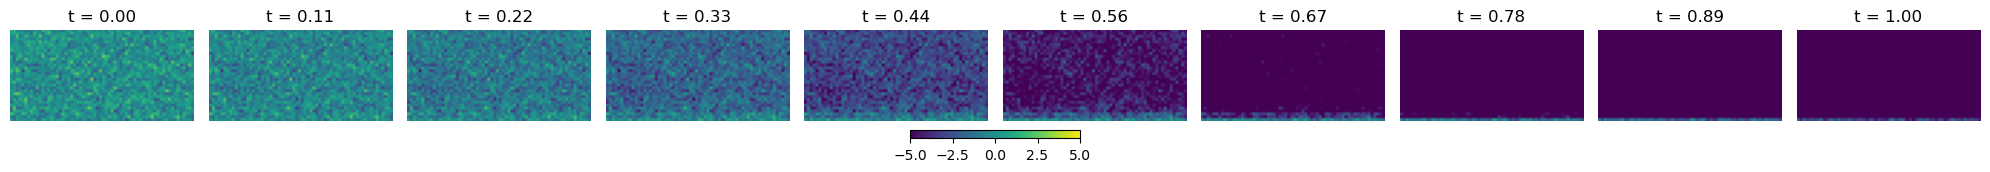

In [121]:
# trajectory.shape: (T=10, B=64, C=10, Nlat=32, Nlon=64) -> one batch (B=0), surface level (C=0)
sol_surface = trajectory[:, 0, 0, :, :]  # shape: [T, Nlat, Nlon]

# plot
fig, axs = plt.subplots(1, 10, figsize=(20, 2))

vmin, vmax = -5, 5
for i in range(10):
    im = axs[i].imshow(sol_surface[i], cmap="viridis", vmin=vmin, vmax=vmax)
    axs[i].set_title(f"t = {i/9:.2f}")
    axs[i].axis("off")

plt.tight_layout()
plt.colorbar(im, ax=axs, orientation='horizontal', fraction=0.05, pad=0.05)
plt.show()

Haha, seem's like it works not at all.<br>
Adding the `denormalized_sol` part also messes up the noise for $t=0$.